In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()

## Coordinate Descent

The idea behind coordinate descent methods is simple. If $f$ is a $k$-dimensional function, we can minimize $f$ by successively minimizing each of the individual dimensions of $f$ in a cyclic fashion, while holding the values of $f$ in the other dimensions fixed. This approach is sometimes referred to as cyclic coordinate descent. The primary advantage of this approach is that it takes an arbitrarily complex $k$-dimensional problem and reduces it to a collection of $k$ one-dimensional problems. The disadvantage is that convergence can often be painfully slow, particularly in problems where $f$ is not well-behaved. In statistics, a popular version of this algorithm is known as *backfitting* and is used to fit generalized additive models.

If we take a simple quadratic function we can take a detailed look at how coordinate descent works. Let’s use the function

$$
f(x, y) = x^2 + y^2 + xy.

$$

We can make a contour plot of this function near the minimum.


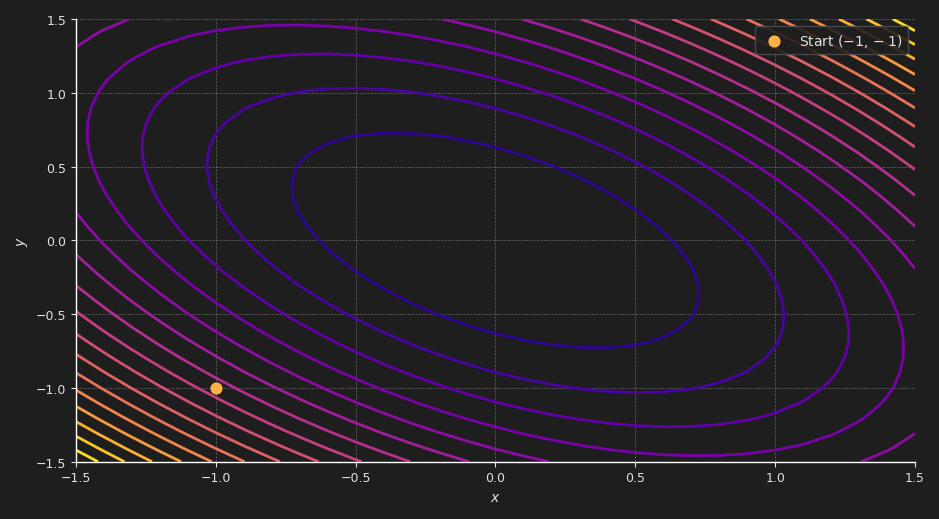

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
f = lambda x, y: x**2 + y**2 + x * y
n = 30
xpts = np.linspace(-1.5, 1.5, n+1)
ypts = np.linspace(-1.5, 1.5, n+1)
xx, yy = np.meshgrid(xpts, ypts)
feval = f(xx, yy)
fig, ax = plt.subplots()
ax.contour(xpts, ypts, feval, levels=20)
ax.scatter([-1], [-1], color=C['orange'], zorder=5, s=60, label='Start $(-1,-1)$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.legend(fontsize=10)
plt.tight_layout()


Let’s take as our initial point $(-1, -1)$ and begin our minimization along the $x$ dimension. We can draw a transect at the $y = -1$ level (thus holding $y$ constant) and attempt to find the minimum along that transect. Because $f$ is a quadratic function, the one-dimensional function induced by holding $y = -1$ is also a quadratic.


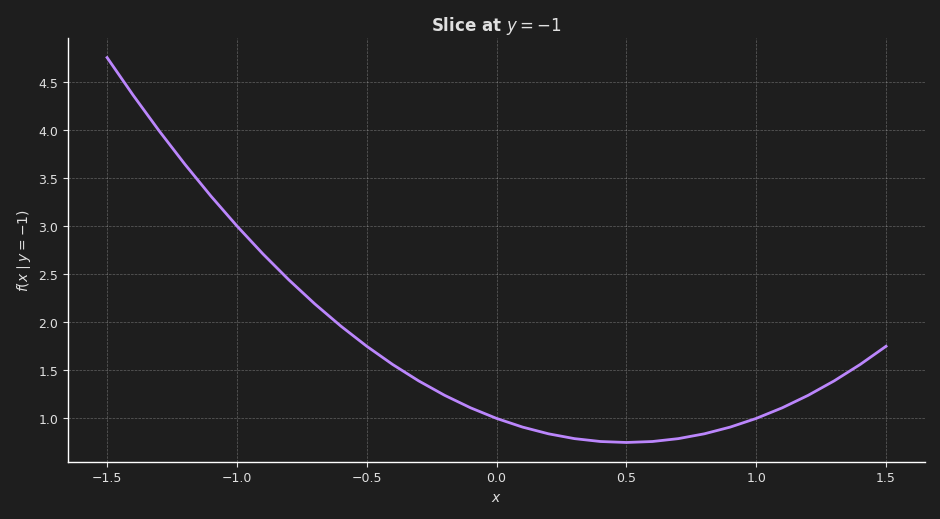

In [3]:
fig, ax = plt.subplots()
ax.plot(xpts, f(xpts, -1), lw=2)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x \\mid y = -1)$')
ax.set_title('Slice at $y = -1$')
plt.tight_layout()


In [4]:
op = optimize.minimize_scalar(lambda x_val: f(x_val, y=-1), bounds=(-1.5, 1.5), method='bounded')
print(f"x minimum: {op.x:.4f}, objective: {op.fun:.4f}")

x minimum: 0.5000, objective: 0.7500


In [5]:
x1 = op.x


We can minimize this one-dimensional function with the `optimize()` function (or we could do it by hand if we’re not lazy).


Granted, we could have done this analytically because we are looking at a simple quadratic function. But in general, you will need a one-dimensional optimizer (like the `scipy.optimize.minimize_scalar`) to complete each of the coordinate descent iterations.

This completes one iteration of the coordinate descent algorithm and our new starting point is $(0.5, -1)$. Let’s store this new $x$ value and move on to the next iteration, which will minimize along the $y$ direction.


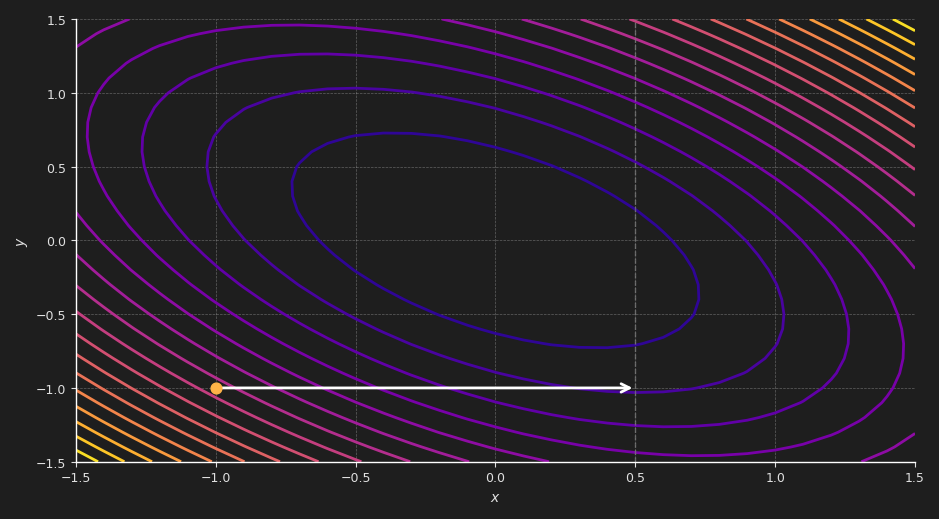

In [6]:
fig, ax = plt.subplots()
ax.contour(xpts, ypts, feval, levels=20)
# Arrow: (-1,-1) -> (x1,-1) — first coordinate step in x direction
ax.annotate('', xy=(x1, -1), xytext=(-1, -1),
            arrowprops=dict(arrowstyle='->', color='white', lw=2, mutation_scale=15))
ax.axvline(x1, linestyle='--', color='gray', lw=1, alpha=0.7)
ax.scatter([-1], [-1], color=C['orange'], zorder=5, s=60)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
plt.tight_layout()


The transect drawn by holding $x = 0.5$ is shown in the Figure above. The one-dimensional function corresponding to that transect is shown below (again, a one-dimensional quadratic function).


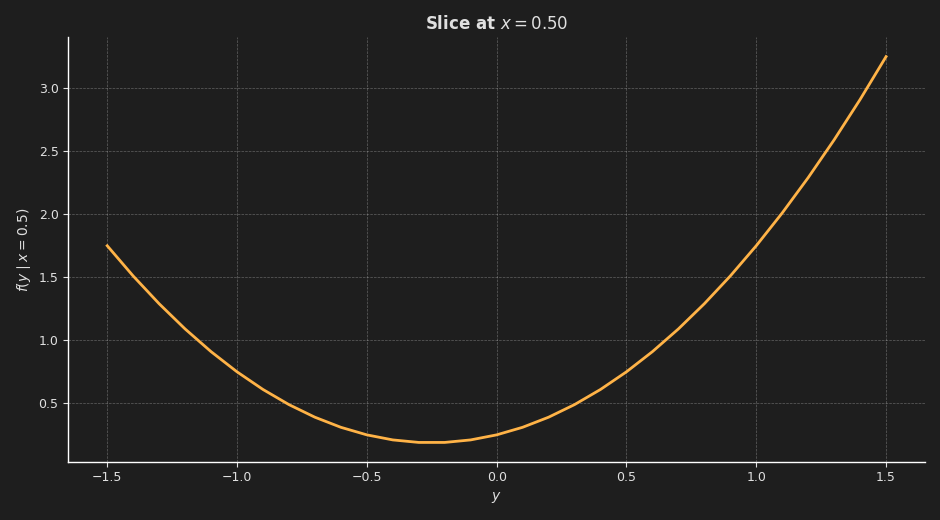

In [7]:
fig, ax = plt.subplots()
ax.plot(ypts, f(x1, ypts), lw=2, color=C['orange'])
ax.set_xlabel('$y$')
ax.set_ylabel(f'$f(y \\mid x = {x1:.1f})$')
ax.set_title(f'Slice at $x = {x1:.2f}$')
plt.tight_layout()


Minimizing this one-dimensional function, we get the following.


In [8]:
op = optimize.minimize_scalar(lambda y_val: f(x1, y_val), bounds=(-1.5, 1.5), method='bounded')
print(f"y minimum: {op.x:.4f}, objective: {op.fun:.4f}")

y minimum: -0.2500, objective: 0.1875


In [9]:
y1 = op.x


This completes another iteration of the coordinate descent algorithm and we can plot our progress below.


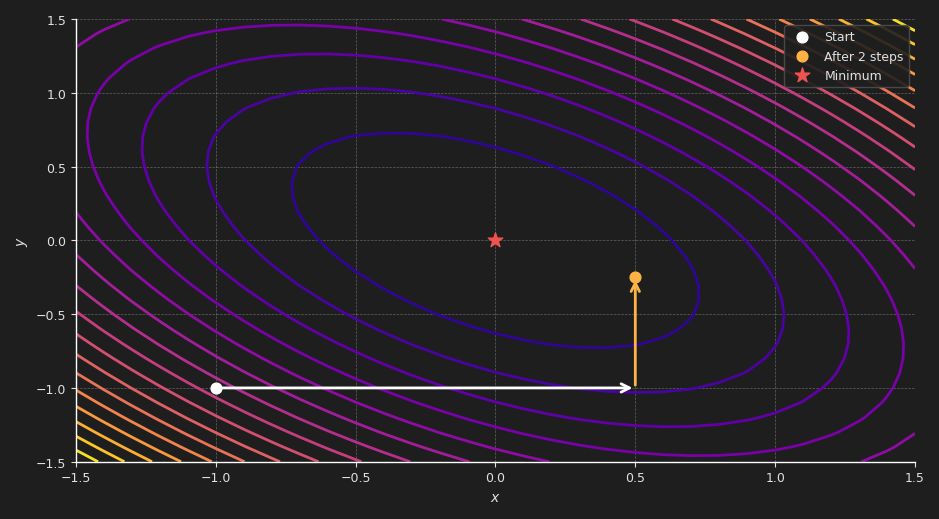

In [10]:
fig, ax = plt.subplots()
ax.contour(xpts, ypts, feval, levels=20)
# Arrow 1: (-1,-1) -> (x1,-1) — x-direction step
ax.annotate('', xy=(x1, -1), xytext=(-1, -1),
            arrowprops=dict(arrowstyle='->', color='white', lw=2, mutation_scale=15))
# Arrow 2: (x1,-1) -> (x1,y1) — y-direction step
ax.annotate('', xy=(x1, y1), xytext=(x1, -1),
            arrowprops=dict(arrowstyle='->', color=C['orange'], lw=2, mutation_scale=15))
ax.scatter([-1], [-1], color='white', zorder=5, s=60, label='Start')
ax.scatter([x1], [y1], color=C['orange'], zorder=5, s=60, label='After 2 steps')
ax.scatter([0], [0], color=C['red'], marker='*', zorder=5, s=120, label='Minimum')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.legend(fontsize=9)
plt.tight_layout()


We can see that after two iterations we are quite a bit closer to the minimum. But we still have a ways to go, given that we can only move along the coordinate axis directions. For a truly quadratic function, this is not an efficient way to find the minimum, particularly when Newton’s method will find the minimum in a single step! Of course, Newton’s method can achieve that kind of performance because it uses two derivatives worth of information. The coordinate descent approach uses no derivative information. There’s no free lunch!

In the above example, the coordinates $x$ and $y$ were moderately correlated but not dramatically so. In general, coordinate descent algorithms show very poor performance when the coordinates are strongly correlated.

The specifics of the coordinate descent algorithm will vary greatly depending on the general function being minimized, but the essential algorithm is as follows. Given a function $f:\mathbb{R}^p\rightarrow\mathbb{R}$,

1. For $j = 1,\dots, p$, minimize $f_j(x) = f(\dots,x_{j-1},x,x_{j+1},\dots)$ wbere $x_1,\dots,x_{j-1},x_{j+1},\dots,x_p$ are all held fixed at their current values. For this use any simple one-dimensional optimizer.
2. Check for convergence. If not converged, go back to 1.

### Convergence Rates

To take a look at the convergence rate for coordinate descent, we will use as an example, a slightly more general version of the quadratic function above,

$$
f(x, y) = x^2 + y^2 + axy,

$$

where here, $a$, represents the amount of correlation or coupling between the $x$ and $y$ coordinates. If $a=0$ there is no coupling and $x$ and $y$ vary independently.

At each iteration of the coordinate descent algorithm, we minimize a one-dimensional version of this function. If we fix $y = c$, then we want to minimize

$$
f_{y=c}(x) = x^2 + c^2 + acx.

$$

Taking the derivative of this with respect to $x$ and setting it equal to zero gives us the minimum at

$$
x_{min} = \frac{-ac}{2}

$$

Similarly, if we fix $x = c$, then we can minimize an analogous function $f_{x=c}(y)$ to get a minimum point of $y_{min} = \frac{-ac}{2}$.

Looking at the coordinate descent algorithm, we can develop the recurrence relationship

$$
\left(
\begin{array}{c}
x_{n+1}\\
y_{n+1}
\end{array}
\right)
=
\left(
\begin{array}{c}
-\frac{a}{2}y_n\\
-\frac{a}{2}x_{n+1}
\end{array}
\right)

$$

Rewinding this back to the inital point, we can then write that

$$
|x_{n} - x_0| = |x_n-0| = \left(\frac{a}{2}\right)^{2n-1} y_0.

$$

where $x_0$ is the minimum point along the $x$ direction. We can similarly say that

$$
|y_n-y_0| = \left(\frac{a}{2}\right)^{2n} x_0.

$$

Looking at the rates of convergence separately for each dimension, we can then show that in the $x$ direction,

$$
\frac{|x_{n+1}-x_0|}{|x_n-x_0|}
=
\frac{
\left(\frac{a}{2}\right)^{2(n+1)-1}y_0
}{
\left(\frac{a}{2}\right)^{2n-1}y_0
}
=
\left(\frac{a}{2}\right)^2.

$$

In order to achieve linear convergence for this algorithm, we must have $\left(\frac{a}{2}\right)^2\in (0, 1)$, which can be true for some values of $a$. But for values of $a\geq 2$ we would not even be able to obtain linear convergence.

In summary, coordinate descent algorithms are conceptually (and computationally) easy to implement but depending on the nature of the target function, convergence may not be possible, even under seemingly reasonable scenarios like the simple one above. Given that we typically do not have very good information about the nature of the target function, particularly in high-dimensional problems, coordinate descent algorithms should be used with care.

### Generalized Additive Models

Before we begin this section, I want to point out that Brian Caffo has a nice [video introduction to generalized additive models](https://youtu.be/f9Rj6SHPHUU) on his YouTube channel.

Generalized additive models represent an interesting class of models that provide nonparametric flexibility to estimate a high-dimensional function without succumbing to the notorious “curse of dimensionality”. In the traditional linear model, we model the outcome $y$ as

$$
y = \alpha + \beta_1x_1 + \beta_2x_2 \cdots + \beta_px_p + \varepsilon.

$$

Generalized additive models replace this formulation with a slightly more general one,

$$
y = \alpha + s_1(x_1\mid \lambda_1) + s_2(x_2\mid \lambda_2) + \cdots + s_p(x_p\mid \lambda_p) + \varepsilon

$$

where $s_1,\dots,s_p$ are *smooth functions* whose smoothness is controled by the parameters $\lambda_1,\dots,\lambda_p$. The key compromise of this model is that rather than estimate an arbitrary smooth $p$-dimensional function, we estimate a series of $p$ one-dimensional functions. This is a much simpler problem but still allows us to capture a variety of nonlinear relationships.

The question now is how do we estimate these smooth functions? Hastie and Tibshirani proposed a *backfitting algorithm* whereby each $s_j()$ would be estimated one-at-a-time while holding all of the other functions constant. This is essentially a coordinate descent algorithm where the coordinates are one-dimensional functions in a function space.

The $s_j()$ functions can be estimated using any kind of smoother. Hastie and Tibshirani used running median smoothers for robustness in many of their examples, but one could use splines, kernel smoothers, or many others.

The backfitting algorithm for additive models works as follows. Given a model of the form

$$
y_i = \alpha + \sum_{j=1}^p s_j(x_{ij}\mid \lambda_j) + \varepsilon_i

$$

where $i=1,\dots,n$,
1. Initialize $\alpha = \frac{1}{n}\sum_{i=1}^n y_i$, $s_1 = s_2 = \cdots = s_p = 0$.

1. Given current values $s_1^{(n)},\dots,s_p^{(n)}$, for $j = 1,\dots,p$, Let

$$
r_{ij} = y_i - \alpha - \sum_{\ell\ne j}s_\ell(x_{i\ell}\mid \lambda_\ell)

$$

so that $r_{ij}$ is the partial residual for predictor $j$ and observation $i$. Given this set of partial residuals $r_{1j},\dots,r_{nj}$, we can estimate $s_j$ by smoothing the relationship between $r_{ij}$ and $x_{ij}$ using any smoother we choose. Essentially, we need to solve the mini-problem

$$
r_{ij} = s_j(x_{ij}\mid\lambda_j) + \varepsilon_i

$$

using standard nonparametric smoothers. As part of this process, we may need to estimate $\lambda_j$ using a procedure like generalized cross-validation or something similar. At the end of this step we have $s_1^{(n+1)},\dots,s_p^{(n+1)}$
2. We can evaluate

$$
\Delta = \sum_{j=1}^p\left\|s_j^{(n+1)} - s_j^{(n)}\right\|

$$

or

$$
\Delta = \frac{\sum_{j=1}^p\left\|s_j^{(n+1)} - s_j^{(n)}\right\|}{\sum_{j=1}^p \left\|s_j^{(n)}\right\|}.

$$

where $\|\cdot\|$ is some reasonable metric. If $\Delta$ is less than some pre-specificed tolerance, we can stop the algorithm. Otherwise, we can go back to Step 2 and do another round of backfitting.
